# A geometria de L1 vs L2

**Tema:** Aprendizado Supervisionado › Regularização

Este notebook constrói, literalmente, o desenho do `teoria.pdf`: as curvas
de nível do erro de mínimos quadrados colidindo com a região restrita de
cada penalidade — um círculo para L2, um losango para L1 — e mostra, num
exemplo 2D construído à mão, exatamente onde a solução regularizada cai.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(9)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Um problema 2D simples, para poder desenhar tudo

In [2]:
n = 200
X = StandardScaler().fit_transform(rng.normal(0, 1, (n, 2)))
beta_real = np.array([2.5, 0.3])  # beta2 tem efeito pequeno de propósito
y = X @ beta_real + rng.normal(0, 1, n)

beta_mq = np.linalg.lstsq(X, y, rcond=None)[0]
print(f"solução de mínimos quadrados (sem restrição): {beta_mq}")

solução de mínimos quadrados (sem restrição): [2.4793683  0.13981707]


## 2. As curvas de nível do erro, centradas na solução sem restrição

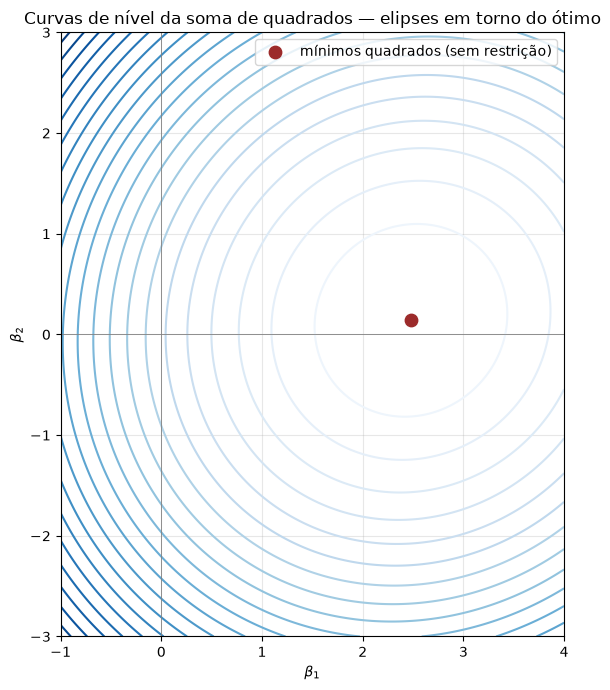

In [3]:
def soma_quadrados(b1_flat, b2_flat, X, y):
    """SQR para cada par (b1, b2), calculado sem materializar um tensor 3D
    gigante -- mais leve em memória para rodar em máquinas modestas."""
    pred = np.outer(X[:, 0], b1_flat) + np.outer(X[:, 1], b2_flat)  # (n, G)
    residuo = y[:, None] - pred
    return np.sum(residuo**2, axis=0)


eixo_b1, eixo_b2 = np.linspace(-1, 4, 150), np.linspace(-3, 3, 150)
b1_grid, b2_grid = np.meshgrid(eixo_b1, eixo_b2)
sqr = soma_quadrados(b1_grid.ravel(), b2_grid.ravel(), X, y).reshape(b1_grid.shape)

fig, ax = plt.subplots(figsize=(7, 7))
ax.contour(b1_grid, b2_grid, sqr, levels=25, cmap="Blues")
ax.scatter([beta_mq[0]], [beta_mq[1]], color=VERMELHO, s=80, zorder=5,
          label="mínimos quadrados (sem restrição)")
ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
ax.set_xlabel(r"$\beta_1$"); ax.set_ylabel(r"$\beta_2$")
ax.set_title("Curvas de nível da soma de quadrados — elipses em torno do ótimo")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 3. Sobrepondo a região restrita: círculo (L2) vs. losango (L1)

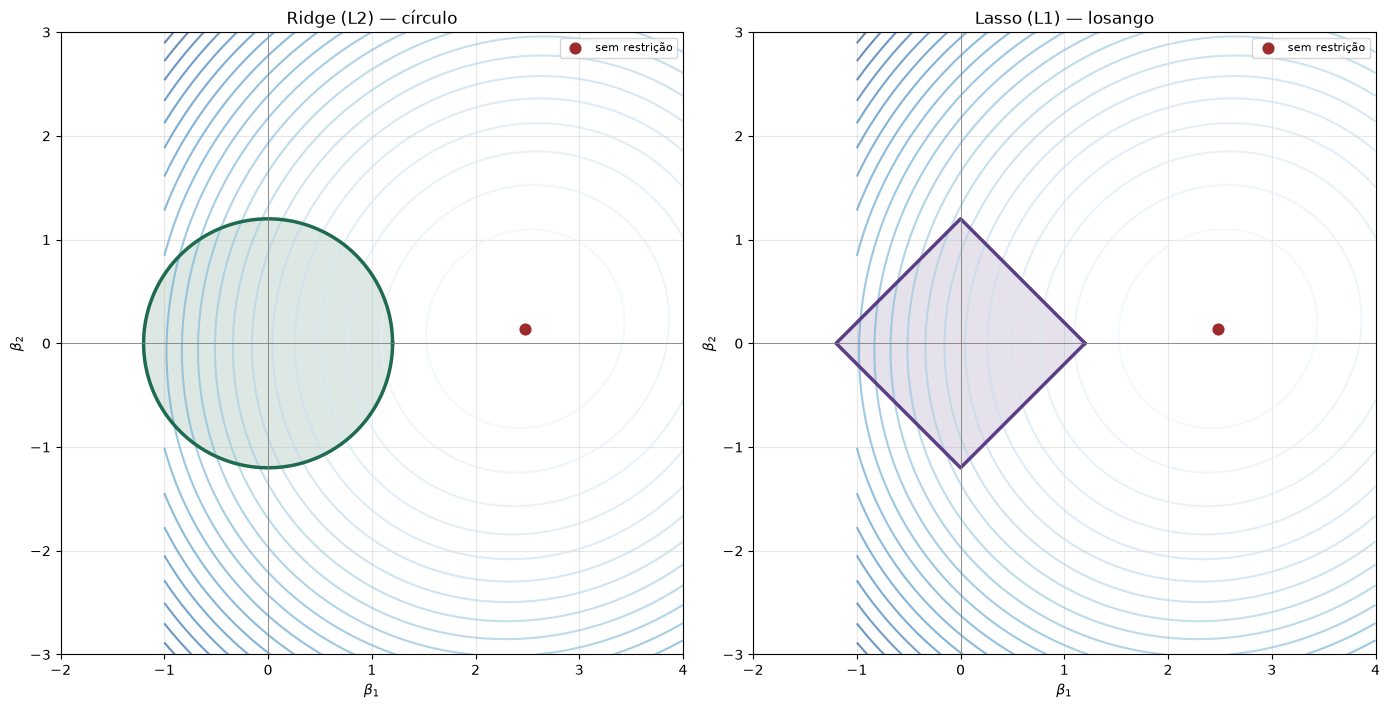

In [4]:
raio = 1.2  # escolhido para a fronteira tocar uma região visível das elipses

theta = np.linspace(0, 2 * np.pi, 200)
circulo_x, circulo_y = raio * np.cos(theta), raio * np.sin(theta)
losango_x = np.array([raio, 0, -raio, 0, raio])
losango_y = np.array([0, raio, 0, -raio, 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (cx, cy, nome, cor) in zip(axes, [
    (circulo_x, circulo_y, "Ridge (L2) — círculo", VERDE),
    (losango_x, losango_y, "Lasso (L1) — losango", ROXO),
]):
    ax.contour(b1_grid, b2_grid, sqr, levels=25, cmap="Blues", alpha=0.6)
    ax.plot(cx, cy, color=cor, lw=2.5)
    ax.fill(cx, cy, color=cor, alpha=0.15)
    ax.scatter([beta_mq[0]], [beta_mq[1]], color=VERMELHO, s=60, zorder=5,
              label="sem restrição")
    ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
    ax.set_xlabel(r"$\beta_1$"); ax.set_ylabel(r"$\beta_2$")
    ax.set_title(nome); ax.set_aspect("equal"); ax.legend(fontsize=8)
    ax.set_xlim(-2, 4); ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()

**O ponto ótimo restrito é onde a menor elipse toca a fronteira da
região.** No losango, essa fronteira tem **quinas exatamente sobre os
eixos** ($\beta_2=0$ ou $\beta_1=0$) — é comum a elipse tocar ali primeiro,
zerando um coeficiente. No círculo, não há quinas em lugar nenhum: o
contato tende a acontecer num ponto onde nenhum coeficiente é exatamente
zero.

## 4. Confirmando com sklearn: onde a solução realmente cai

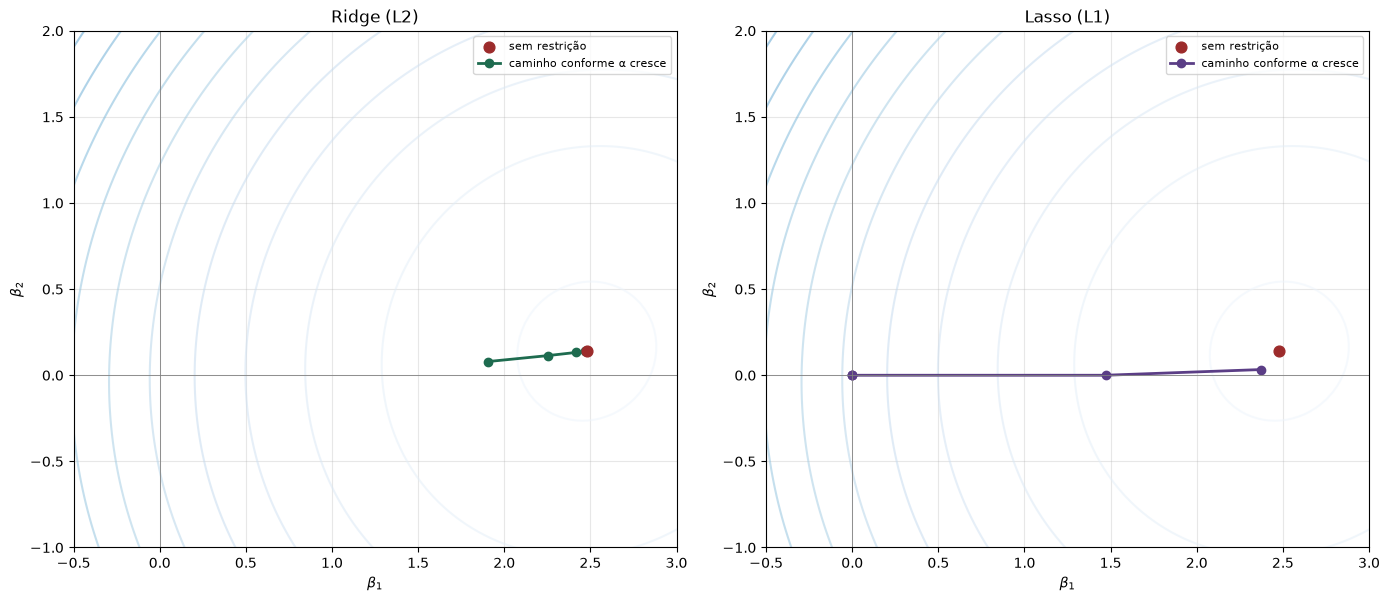

caminho do Ridge (β1, β2):
  α=  0.1: [2.47811969 0.13966755]
  α=  1.0: [2.46693883 0.13833213]
  α=  5.0: [2.41844737 0.13261359]
  α= 20.0: [2.25246987 0.11394164]
  α= 60.0: [1.90423611 0.07931583]

caminho do Lasso (β1, β2):
  α=  0.1: [2.37255089 0.0329997 ]
  α=  1.0: [1.47044479 0.        ]
  α=  5.0: [0. 0.]
  α= 20.0: [0. 0.]
  α= 60.0: [0. 0.]


In [5]:
alphas = [0.1, 1, 5, 20, 60]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (Modelo, nome, cor) in zip(axes, [
    (Ridge, "Ridge (L2)", VERDE), (Lasso, "Lasso (L1)", ROXO),
]):
    ax.contour(b1_grid, b2_grid, sqr, levels=20, cmap="Blues", alpha=0.5)
    ax.scatter([beta_mq[0]], [beta_mq[1]], color=VERMELHO, s=60, zorder=5,
              label="sem restrição")
    trajetoria = []
    for alpha in alphas:
        modelo = Modelo(alpha=alpha, fit_intercept=False).fit(X, y)
        trajetoria.append(modelo.coef_)
    trajetoria = np.array(trajetoria)
    ax.plot(trajetoria[:, 0], trajetoria[:, 1], "o-", color=cor, lw=2, ms=6,
           label="caminho conforme α cresce")
    ax.axhline(0, color="gray", lw=0.6); ax.axvline(0, color="gray", lw=0.6)
    ax.set_title(nome); ax.set_xlabel(r"$\beta_1$"); ax.set_ylabel(r"$\beta_2$")
    ax.legend(fontsize=8); ax.set_aspect("equal")
    ax.set_xlim(-0.5, 3); ax.set_ylim(-1, 2)
plt.tight_layout(); plt.show()

print("caminho do Ridge (β1, β2):")
for alpha in alphas:
    print(f"  α={alpha:>5.1f}: {Ridge(alpha=alpha, fit_intercept=False).fit(X, y).coef_}")
print("\ncaminho do Lasso (β1, β2):")
for alpha in alphas:
    print(f"  α={alpha:>5.1f}: {Lasso(alpha=alpha, fit_intercept=False).fit(X, y).coef_}")

**Observe o caminho do Lasso:** $\beta_2$ (o coeficiente com efeito real
pequeno, 0,3) deve chegar a exatamente zero para $\alpha$ grande o
suficiente, enquanto o caminho do Ridge mantém os dois coeficientes
diferentes de zero, ambos encolhendo suavemente.

## O que levar deste notebook

- Regularização é, geometricamente, resolver mínimos quadrados **dentro**
  de uma região restrita ao redor da origem — círculo para L2, losango
  para L1.
- Quinas do losango caem exatamente sobre os eixos — por isso Lasso produz
  coeficientes exatamente zero, e Ridge (sem quinas) não.
- O caminho de coeficientes conforme a penalidade cresce, calculado por
  `sklearn`, reproduz exatamente essa geometria — não é coincidência, é a
  mesma matemática vista de dois ângulos.

→ Próximo: **Elastic Net e ajuste de alpha**, combinando as duas
penalidades e escolhendo a força certa por validação cruzada.